Movie studios often estimate a film’s total box office revenue based on its p**erformance in the first few days**. Suppose we are interested in predicting the **average daily revenue** of a new blockbuster movie.

We assume that the daily revenue (in millions of dollars) follows a normal distribution with an unknown mean $\mu$, but a known variance $\sigma^2$. Before the movie is released, we have a prior belief about $\mu$, which we update once we observe the first few days of box office revenue.

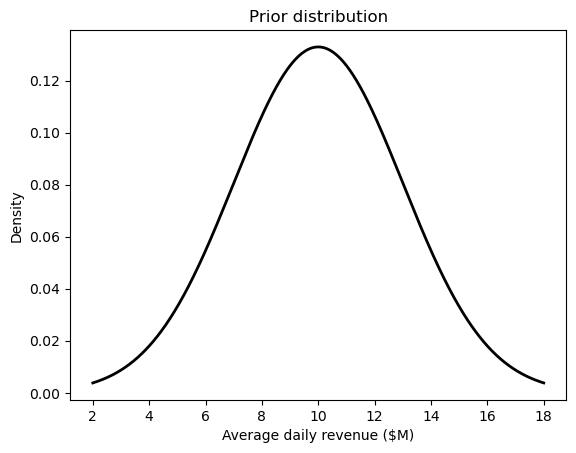

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import scipy.integrate as integrate

## we assume our prior belief for mu is 10, and for sigma 3
# Prior parameters
mu_0, tau_0 = 10, 3  # Prior mean and std dev
rv = norm(loc=mu_0, scale = tau_0)

prior = lambda x: rv.pdf(x)

x = np.linspace(2, 18, 1000)
fig, ax = plt.subplots(1, 1)
plt.xlabel("Average daily revenue ($M)")
plt.ylabel("Density")
plt.title('Prior distribution')
ax.plot(x, prior(x), 'k-', lw=2)
plt.show()

The observed daily revenue $X$ is normally distributed with a known variance $\sigma^2 = 4$, that is, $X_i \sim \mathcal{N}(\mu, 4) $.

In [2]:
# Known variance of daily revenue
sigma = 2  # Standard deviation

# Observed data (box office revenue in first 4 days)
data = np.array([12, 8, 15, 9])
n = len(data)
x_bar = np.mean(data)

Next we define the likelihood $P[\mathcal{X} | \mu]$ as the product of normal densities of the observed data. We will then define the unormalized posterior and find the normalization constant by intergrating.

In [3]:
# Define likelihood function (product of normal densities)
likelihood = lambda mu: np.prod(norm.pdf(data, mu, sigma))

# Unnormalized posterior (joint of prior and likelihood)
posterior_unnorm = lambda mu: prior(mu) * likelihood(mu)

# Compute marginal likelihood (normalizing constant)
evidence = integrate.quad(posterior_unnorm, -np.inf, np.inf)[0]

# Normalize posterior
posterior = lambda mu: posterior_unnorm(mu) / evidence

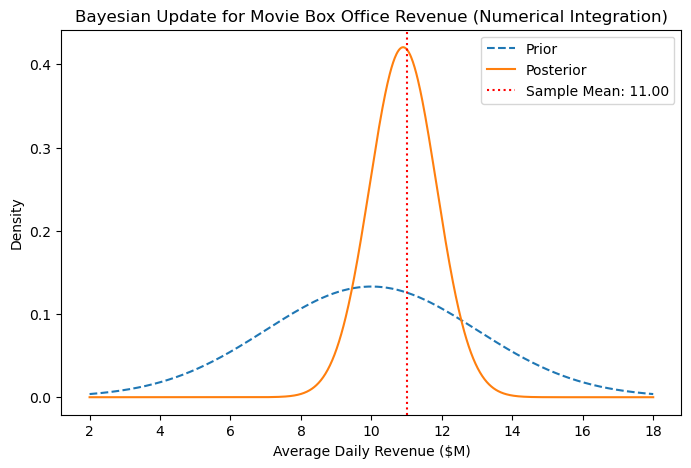

In [4]:
# Plot prior and posterior distributions
x = np.linspace(2, 18, 1000)

plt.figure(figsize=(8,5))
plt.plot(x, prior(x), label="Prior", linestyle='dashed')
plt.plot(x, [posterior(mu) for mu in x], label="Posterior")
plt.axvline(x_bar, color='red', linestyle='dotted', label=f"Sample Mean: {x_bar:.2f}")
plt.legend()
plt.xlabel("Average Daily Revenue ($M)")
plt.ylabel("Density")
plt.title("Bayesian Update for Movie Box Office Revenue (Numerical Integration)")
plt.show()

What is the probability that the movie will do more than 12 millions on a day? We will need to intergrate the posterior between the value of 12 and infinity.

In [6]:
# Compute probability of revenue being > $12M, prob_above_12

prob_above_12 = integrate.quad(posterior, 10, np.inf)[0]
print(f"The probability of a daily revenue higher than 12m is: {prob_above_12:.3f}")

The probability of a daily revenue higher than 12m is: 0.829
